# Data Loading and Preprocessing

In [1]:
import os
import numpy as np
import rasterio
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

# config
DATASET_DIR   = "C:\\Users\\uceda\\Documents\\uni\\master\\ENLIGHT\\course\\data\\dataset\\s2\\200m"
TRAIN_LST     = "../data/train_filenames.lst"
TEST_LST      = "../data/test_filenames.lst"
CACHE_DIR     = "../data/cache"          # where .npy files are saved
MAX_H, MAX_W  = 21, 21
NUM_CLASSES   = 20

species_list = [
    "Abies_alba", "Acer_pseudoplatanus", "Alnus_spec", "Betula_spec",
    "Cleared", "Fagus_sylvatica", "Fraxinus_excelsior", "Larix_decidua",
    "Larix_kaempferi", "Picea_abies", "Pinus_nigra", "Pinus_strobus",
    "Pinus_sylvestris", "Populus_spec", "Prunus_spec", "Pseudotsuga_menziesii",
    "Quercus_petraea", "Quercus_robur", "Quercus_rubra", "Tilia_spec",
]

os.makedirs(CACHE_DIR, exist_ok=True)

In [2]:
# load filenames
with open(TRAIN_LST) as f:
    train_filenames = f.read().splitlines()
with open(TEST_LST) as f:
    test_filenames = f.read().splitlines()

print(f"Train: {len(train_filenames)} | Test: {len(test_filenames)}")

Train: 45337 | Test: 5044


In [18]:
# extract index label from filename
def filename_to_idx(filename):
    for i, species in enumerate(species_list):
        if species in filename:
            return i
    return 0 # Default fallback

# load and pad one .tif
def load_tif(filename):
    path = os.path.join(DATASET_DIR, filename)
    with rasterio.open(path) as src:
        img = src.read().astype(np.float32)      # (12, H, W)
    pad_h = MAX_H - img.shape[1]
    pad_w = MAX_W - img.shape[2]
    img = np.pad(img, ((0, 0), (0, pad_h), (0, pad_w)), mode='constant')
    return img.flatten()                          # (5292,)

def compute_vegetation_indices(img: np.ndarray) -> np.ndarray:
    """
    img: (12, H, W) -> extract B1 to B12
    Returns: (9, H, W) -> computed VIs
    """
    # Unpack all 12 bands
    B1, B2, B3, B4, B5, B6, B7, B8, B8A, B9, B11, B12 = img

    # Avoid division by zero
    eps = 1e-8

    # 1. NDVI: (NIR - Red) / (NIR + Red)
    ndvi = (B8 - B4) / (B8 + B4 + eps)

    # 2. SRVI: (NIR - Red) / (NIR + Red + Green)
    srvi = (B8 - B4) / (B8 + B4 + B3 + eps)

    # 3. SRWI: (SWIR - NIR) / (SWIR + NIR)
    srwi = (B11 - B8) / (B11 + B8 + eps)

    # 4. EVI: 2.5 * (NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1)
    evi = 2.5 * (B8 - B4) / (B8 + 6*B4 - 7.5*B2 + 1 + eps)

    # 5. NDRE: (NIR - Red Edge 3) / (NIR + Red Edge 3)
    ndre = (B8 - B7) / (B8 + B7 + eps)

    # 6. IRECI: (NIR - Red Edge 3) / (NIR + Red Edge 3) * (NIR / Red)
    ireci = (B8 - B7) / (B8 + B7 + eps) * (B8 / (B4 + eps))

    # 7. PSRI: (Red - Green) / (NIR)
    psri = (B4 - B3) / (B8 + eps)

    # 8. NDMI: (NIR - SWIR) / (NIR + SWIR)
    ndmi = (B8 - B11) / (B8 + B11 + eps)

    # 9. GLI: (2*Green - Blue - Red) / (2*Green + Blue + Red)
    gli = (2*B3 - B2 - B4) / (2*B3 + B2 + B4 + eps)

    # Stack all indices
    indices = np.stack([
        ndvi, srvi, srwi, evi, ndre, ireci, psri, ndmi, gli
    ], axis=0)  # Shape: (9, H, W)

    return indices


def load_tif_with_visi(filename):
    path = os.path.join(DATASET_DIR, filename)
    with rasterio.open(path) as src:
        img = src.read().astype(np.float32)  # (12, H, W)

    # Pad to 21x21
    pad_h = MAX_H - img.shape[1]
    pad_w = MAX_W - img.shape[2]
    img = np.pad(img, ((0, 0), (0, pad_h), (0, pad_w)), mode='constant')

    # Compute VIs
    visi = compute_vegetation_indices(img)  # (9, 21, 21)

    # Flatten to (9 * 21 * 21,) = 3969 features
    return visi.flatten()  # (3969,)


# build or load cached arrays
def build_split(filenames, split_name):
    X_path = os.path.join(CACHE_DIR, f"X_{split_name}.npy")
    y_path = os.path.join(CACHE_DIR, f"y_{split_name}.npy")

    if os.path.exists(X_path) and os.path.exists(y_path):
        print(f"Loading cached {split_name} arrays...")
        X = np.load(X_path)
        y = np.load(y_path)
        return X, y

    print(f"Building {split_name} arrays from .tif files...")
    X_list, y_list = [], []
    for i, fn in enumerate(filenames):
        if i % 500 == 0:
            print(f"  {i}/{len(filenames)}")
        X_list.append(load_tif(fn))
        y_list.append(filename_to_idx(fn))

    X = np.array(X_list, dtype=np.float32)   # (N, 5292)
    y = np.array(y_list, dtype=np.int64)     # (N,)

    np.save(X_path, X)
    np.save(y_path, y)
    print(f"  Saved to {X_path} and {y_path}")
    return X, y

def build_split_visi(filenames, split_name):
    X_path = os.path.join(CACHE_DIR, f"X_{split_name}_visi.npy")
    y_path = os.path.join(CACHE_DIR, f"y_{split_name}.npy")

    if os.path.exists(X_path) and os.path.exists(y_path):
        print(f"Loading cached {split_name} VI arrays...")
        X = np.load(X_path, allow_pickle=True)  # Keep as list of arrays
        y = np.load(y_path)
        return X, y

    print(f"Building {split_name} VI arrays from .tif files...")
    X_list, y_list = [], []
    for i, fn in enumerate(filenames):
        if i % 500 == 0:
            print(f"  {i}/{len(filenames)}")
        X_list.append(load_tif_with_visi(fn))  # (3969,)
        y_list.append(filename_to_idx(fn))

    X = np.array(X_list, dtype=np.float32)  # (N, 3969)
    y = np.array(y_list, dtype=np.int64)

    # Save flattened version
    np.save(X_path, X)
    np.save(y_path, y)
    print(f"  Saved to {X_path} and {y_path}")

    # Now, recompute VI maps (9, 21, 21) for correlation analysis
    # We'll reconstruct from X (flattened) → reshape to (9, 21, 21)
    X_maps = []
    for x_flat in X:
        # Reshape from (3969,) → (9, 21, 21)
        x_map = x_flat.reshape(9, 21, 21)
        X_maps.append(x_map)

    X_maps = np.array(X_maps)  # (N, 9, 21, 21)

    # Save maps for correlation
    maps_path = os.path.join(CACHE_DIR, f"X_{split_name}_visi_maps.npy")
    np.save(maps_path, X_maps)
    print(f"  Saved VI maps to {maps_path}")

    return X, y

In [7]:
X_train, y_train = build_split(train_filenames, "train")
X_test,  y_test  = build_split(test_filenames,  "test")

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")


Loading cached train arrays...
Loading cached test arrays...
X_train: (45337, 5292) | y_train: (45337, 20)
X_test:  (5044, 5292)  | y_test:  (5044, 20)


# Vegetation Indices


In [8]:
def compute_aggregated_visi(img: np.ndarray) -> np.ndarray:
    visi = compute_vegetation_indices(img)  # (9, 21, 21)
    # Compute mean, std, min, max per VI
    features = []
    for i in range(9):
        features.append(visi[i].mean())
        features.append(visi[i].std())
        features.append(visi[i].min())
        features.append(visi[i].max())
    return np.array(features)  # (36,)

In [13]:
# Test one file
test_img = load_tif_with_visi(train_filenames[0])
print(test_img.shape)  # Should be (3969,)

(3969,)


In [19]:
X_train_visi, y_train_visi = build_split_visi(train_filenames, "train_visi")
X_test_visi, y_test_visi = build_split_visi(test_filenames, "test_visi")

print(f"X_train: {X_train_visi.shape} | y_train: {y_train_visi.shape}")
print(f"X_test:  {X_test_visi.shape}  | y_test:  {y_test_visi.shape}")



Building train_visi VI arrays from .tif files...
  0/45337
  500/45337
  1000/45337
  1500/45337
  2000/45337
  2500/45337
  3000/45337
  3500/45337
  4000/45337
  4500/45337
  5000/45337
  5500/45337
  6000/45337
  6500/45337
  7000/45337
  7500/45337
  8000/45337
  8500/45337
  9000/45337
  9500/45337
  10000/45337
  10500/45337
  11000/45337
  11500/45337
  12000/45337
  12500/45337
  13000/45337
  13500/45337
  14000/45337
  14500/45337
  15000/45337
  15500/45337
  16000/45337
  16500/45337
  17000/45337
  17500/45337
  18000/45337
  18500/45337
  19000/45337
  19500/45337
  20000/45337
  20500/45337
  21000/45337
  21500/45337
  22000/45337
  22500/45337
  23000/45337
  23500/45337
  24000/45337
  24500/45337
  25000/45337
  25500/45337
  26000/45337
  26500/45337
  27000/45337
  27500/45337
  28000/45337
  28500/45337
  29000/45337
  29500/45337
  30000/45337
  30500/45337
  31000/45337
  31500/45337
  32000/45337
  32500/45337
  33000/45337
  33500/45337
  34000/45337
  34500/4

In [27]:
X_train_maps = np.load(os.path.join(CACHE_DIR, "X_train_visi_visi_maps.npy"), allow_pickle=False)
print(X_train_maps.shape)  # Should be (45337, 9, 21, 21)

(45337, 9, 21, 21)


In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: Compute correlation across all pixels in a single patch
def compute_correlation_matrix(X: np.ndarray) -> np.ndarray:
    """
    X: (N, 9, H, W) → compute correlation matrix across features
    Returns: (9, 9) correlation matrix
    """
    N, C, H, W = X.shape  # C=9, H=21, W=21

    # Reshape to (N, 9, H*W) → (N, 9, 441)
    X_flat = X.reshape(N, C, -1)  # (N, 9, 441)

    # Compute mean across spatial dimension (H*W)
    X_mean = X_flat.mean(axis=2, keepdims=True)  # (N, 9, 1)

    # Center the data
    X_centered = X_flat - X_mean  # (N, 9, 441)

    # Compute covariance matrix: (9, 9)
    # Sum over N and spatial dims
    X_cov = np.einsum('nci,ndi->cd', X_centered, X_centered) / (N * H * W - 1)

    # Compute standard deviations
    X_std = np.sqrt(np.diag(X_cov))  # (9,)

    # Compute correlation matrix
    corr = X_cov / (X_std[:, None] * X_std[None, :])

    return corr

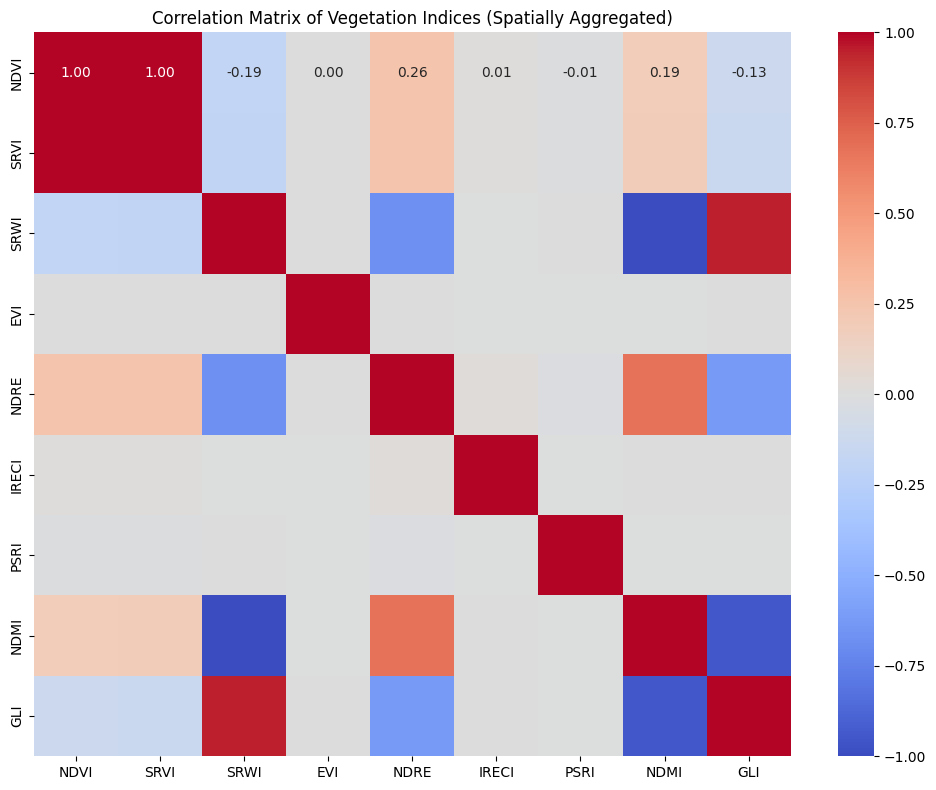

In [31]:
# Load maps
X_train_maps = np.load(os.path.join(CACHE_DIR, "X_train_visi_visi_maps.npy"), allow_pickle=False)

# Compute correlation
corr = compute_correlation_matrix(X_train_maps)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=['NDVI', 'SRVI', 'SRWI', 'EVI', 'NDRE', 'IRECI', 'PSRI', 'NDMI', 'GLI'],
            yticklabels=['NDVI', 'SRVI', 'SRWI', 'EVI', 'NDRE', 'IRECI', 'PSRI', 'NDMI', 'GLI'])
plt.title("Correlation Matrix of Vegetation Indices (Spatially Aggregated)")
plt.tight_layout()
plt.savefig("vi_correlation_heatmap.png", dpi=150)
plt.show()

In [ ]:
[
    "NDVI",       # Core greenness
    "EVI",        # Better for dense vegetation
    "NDRE",       # Red edge sensitivity
    "PSRI",       # Senescence indicator
    "NDMI",       # Moisture
    "SRWI",       # Water stress
    "GLI"         # Greenness (alternative)
]

In [ ]:
def compute_aggregated_visi(img: np.ndarray) -> np.ndarray:
    visi = compute_vegetation_indices(img)  # (9, 21, 21)
    features = []
    for i in range(9):
        features.append(visi[i].mean())
        features.append(visi[i].std())
        features.append(visi[i].min())
        features.append(visi[i].max())
    return np.array(features)  # (36,)

In [ ]:
# Replace this:
# X_train = np.load("X_train.npy")  # (45337, 5292)

# With this:
X_train = np.array([compute_aggregated_visi(img) for img in X_train_visi.reshape(-1, 12, 21, 21)])

# Then normalize and train your model.

# Random Forest baseline

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, average_precision_score
import pandas as pd

y_train_idx = np.argmax(y_train, axis=1)   # (N,)  integer class labels
y_test_idx  = np.argmax(y_test,  axis=1)

print("Training Random Forest (single-label, argmax labels)...")
rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train_idx)

# Predictions (class indices)
y_pred_idx = rf.predict(X_test)                    # (N,) integer
y_pred_proba = rf.predict_proba(X_test)            # (N, 20) probabilities

# Convert predictions back to one-hot so we can reuse the same metric helpers
y_pred_oh = np.zeros((len(y_pred_idx), NUM_CLASSES), dtype=int)
y_pred_oh[np.arange(len(y_pred_idx)), y_pred_idx] = 1

# Evaluation
print(f"RF Accuracy: {accuracy_score(y_test_idx, y_pred_idx):.4f}")
report = classification_report(y_test_idx, y_pred_idx, target_names=species_list, output_dict=True)

# Aggregate metrics (mirror MLP format)
rf_results = {}
for avg in ('micro', 'weighted'):
    rf_results[avg] = {
        'precision': precision_score(y_test_idx, y_pred_idx, average=avg, zero_division=0),
        'recall':    recall_score(   y_test_idx, y_pred_idx, average=avg, zero_division=0),
        'f1':        f1_score(       y_test_idx, y_pred_idx, average=avg, zero_division=0),
        'mAP':       average_precision_score(y_test, y_pred_proba, average=avg),
    }

# Store final-epoch RF metrics in a history-like dict so the comparison cell can plot it
rf_final = rf_results   # will be referenced in comparison cell

# Per-class table
df_rf = pd.DataFrame(report).transpose()
print("\nFinal RF Performance (summary):")
print(f"{'Metric':<15} {'Micro':>10} {'Weighted':>10}")
print("-"*37)
for metric in ('precision', 'recall', 'f1', 'mAP'):
    print(f"{metric:<15} {rf_results['micro'][metric]:>10.4f} {rf_results['weighted'][metric]:>10.4f}")
print()
display(df_rf.iloc[:20])


# Applying regularization

In [ ]:
import torch.nn as nn

class ImprovedMLP(nn.Module):
    def __init__(self, in_dim=5292, hidden_dim=512, out_dim=20):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim), # Stabilizes training
            nn.ReLU(),
            nn.Dropout(0.3),            # Prevents overfitting
            
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(hidden_dim, out_dim)
        )
        
    def forward(self, x):
        return self.net(x)

model = ImprovedMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [9]:
import os
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
from sklearn.metrics import recall_score, precision_score, f1_score, average_precision_score
import matplotlib.pyplot as plt

CACHE_DIR   = "../data/cache"
MODEL_DIR   = "../data/models"
os.makedirs(MODEL_DIR, exist_ok=True)

NUM_CLASSES = 20
EPOCHS      = 150
BATCH_SIZE  = 32
LR_MIN      = 0.00005
LR_MAX      = 0.001

# load cached arrays
print("Loading cached arrays...")
X_train = np.load(os.path.join(CACHE_DIR, "X_train.npy"))
y_train = np.load(os.path.join(CACHE_DIR, "y_train.npy"))
X_test  = np.load(os.path.join(CACHE_DIR, "X_test.npy"))
y_test  = np.load(os.path.join(CACHE_DIR, "y_test.npy"))
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")


Loading cached arrays...
X_train: (45337, 5292) | y_train: (45337, 20)
X_test:  (5044, 5292)  | y_test:  (5044, 20)


In [ ]:
# normalize
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0) + 1e-8
X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std

In [ ]:
# tensors & dataloaders
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(np.argmax(y_train, axis=1), dtype=torch.long)  # CE needs class indices
X_test_t  = torch.tensor(X_test)
y_test_t  = torch.tensor(np.argmax(y_test,  axis=1), dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
impr_model  = ImprovedMLP().to(device)
print(f"\nUsing device: {device}")

In [ ]:
# loss, optimizer, cyclic LR 
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(impr_model.parameters(), lr=LR_MIN)

# step_size_up = half cycle length; 4 cycles over 150 epochs is a common choice
scheduler = torch.optim.lr_scheduler.CyclicLR(
    optimizer,
    base_lr    = LR_MIN,
    max_lr     = LR_MAX,
    step_size_up = len(train_loader) * 4,   # cycle up over ~4 epochs
    mode       = "triangular",
    cycle_momentum = False,                  # Adam has no momentum param
)

In [ ]:
#metrics helper 
def compute_metrics(y_true_idx, y_pred_prob):
    """y_true_idx: (N,) integer class indices; y_pred_prob: (N, C) softmax/sigmoid probs."""
    y_pred_idx = np.argmax(y_pred_prob, axis=1)
    # one-hot encode for mAP
    n_cls = y_pred_prob.shape[1]
    y_true_oh = np.eye(n_cls)[y_true_idx]

    metrics = {}
    for avg in ("micro", "weighted"):
        metrics[f"precision_{avg}"] = precision_score(y_true_idx, y_pred_idx, average=avg, zero_division=0)
        metrics[f"recall_{avg}"]    = recall_score(   y_true_idx, y_pred_idx, average=avg, zero_division=0)
        metrics[f"f1_{avg}"]        = f1_score(       y_true_idx, y_pred_idx, average=avg, zero_division=0)
        metrics[f"mAP_{avg}"]       = average_precision_score(y_true_oh, y_pred_prob, average=avg)
    return metrics

In [ ]:
# training loop
history_regu = {
    "train_loss": [], "test_loss": [],
    "f1_micro": [],   "f1_weighted": [],
    "mAP_micro": [],  "mAP_weighted": [],
}

for epoch in range(1, EPOCHS + 1):

    # train
    impr_model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(impr_model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_loss += loss.item() * len(X_batch)
    train_loss /= len(train_loader.dataset)

    # eval
    impr_model.eval()
    test_loss = 0.0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = impr_model(X_batch)
            test_loss += criterion(logits, y_batch).item() * len(X_batch)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(y_batch.cpu().numpy())
    test_loss /= len(test_loader.dataset)

    y_prob = np.concatenate(all_probs,  axis=0)
    y_true = np.concatenate(all_labels, axis=0)
    m = compute_metrics(y_true, y_prob)

    history_regu["train_loss"].append(train_loss)
    history_regu["test_loss"].append(test_loss)
    history_regu["f1_micro"].append(m["f1_micro"])
    history_regu["f1_weighted"].append(m["f1_weighted"])
    history_regu["mAP_micro"].append(m["mAP_micro"])
    history_regu["mAP_weighted"].append(m["mAP_weighted"])

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | "
              f"F1 micro: {m['f1_micro']:.4f} | F1 weighted: {m['f1_weighted']:.4f} | "
              f"mAP micro: {m['mAP_micro']:.4f} | mAP weighted: {m['mAP_weighted']:.4f}")


In [ ]:
# save model 
model_path = os.path.join(MODEL_DIR, "mlp_s2_200m_regu.pt")
torch.save({
    "model_state_dict": impr_model.state_dict(),
    "mean": mean,
    "std":  std,
}, model_path)
print(f"\nModel saved to {model_path}")

In [ ]:
# plot
epochs_x = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_x, history_regu["train_loss"], label="Train")
axes[0].plot(epochs_x, history_regu["test_loss"],  label="Test")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_x, history_regu["f1_micro"],    label="F1 micro")
axes[1].plot(epochs_x, history_regu["f1_weighted"], label="F1 weighted")
axes[1].set_title("F1 Score"); axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(True)

axes[2].plot(epochs_x, history_regu["mAP_micro"],    label="mAP micro")
axes[2].plot(epochs_x, history_regu["mAP_weighted"], label="mAP weighted")
axes[2].set_title("Mean Average Precision"); axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 1); axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plot_path = os.path.join(MODEL_DIR, "training_curves_regu.png")
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved to {plot_path}")

In [ ]:
# final evaluation
impr_model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        all_probs.append(torch.sigmoid(impr_model(X_batch)).cpu().numpy())
        all_labels.append(y_batch.numpy())

y_prob = np.concatenate(all_probs,  axis=0)   # (N_test, 20)
y_true = np.concatenate(all_labels, axis=0)   # (N_test, 20)
y_pred_idx = np.argmax(y_prob, axis=1)
y_true_oh  = np.eye(NUM_CLASSES, dtype=int)[y_true.astype(int)]
y_pred_oh  = np.eye(NUM_CLASSES, dtype=int)[y_pred_idx]

# per-class metrics
per_class = {}
for i, species in enumerate(species_list):
    per_class[species] = {
        "precision": precision_score(y_true_oh[:, i], y_pred_oh[:, i], zero_division=0),
        "recall":    recall_score(   y_true_oh[:, i], y_pred_oh[:, i], zero_division=0),
        "f1":        f1_score(       y_true_oh[:, i], y_pred_oh[:, i], zero_division=0),
        "AP":        average_precision_score(y_true_oh[:, i], y_prob[:, i]),
        "support":   int(y_true_oh[:, i].sum()),
    }

# aggregate: micro + weighted
results = {}
for avg in ("micro", "weighted"):
    results[avg] = {
        "precision": precision_score(y_true_oh, y_pred_oh, average=avg, zero_division=0),
        "recall":    recall_score(   y_true_oh, y_pred_oh, average=avg, zero_division=0),
        "f1":        f1_score(       y_true_oh, y_pred_oh, average=avg, zero_division=0),
        "mAP":       average_precision_score(y_true_oh, y_prob, average=avg),
    }

# print summary table
print("\n" + "="*75)
print(f"{'FINAL TEST EVALUATION':^75}")
print("="*75)
print(f"\n{'Metric':<15} {'Micro':>12} {'Weighted':>12}")
print("-"*40)
for metric in ("precision", "recall", "f1", "mAP"):
    print(f"{metric:<15} {results['micro'][metric]:>12.4f} {results['weighted'][metric]:>12.4f}")

# print per-class table 
print(f"\n{'Per-class breakdown':^75}")
print("-"*75)
print(f"{'Species':<30} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AP':>10} {'Support':>8}")
print("-"*75)
for species, m in sorted(per_class.items(), key=lambda x: -x[1]["support"]):
    print(f"{species:<30} {m['precision']:>10.4f} {m['recall']:>10.4f} "
          f"{m['f1']:>10.4f} {m['AP']:>10.4f} {m['support']:>8d}")
print("="*75)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# ── Final test metric values (from printed eval output) ─────────
# RF  (cell 15 output)
rf_vals = {
    'Precision\n(weighted)': rf_final['weighted']['precision'],
    'Recall\n(weighted)':    rf_final['weighted']['recall'],
    'F1\n(weighted)':        rf_final['weighted']['f1'],
    'mAP\n(weighted)':       rf_final['weighted']['mAP'],
}


mlp_vals = {
    'Precision\n(weighted)': 0.5089,   # from cell 13 printed output
    'Recall\n(weighted)':    0.5040,
    'F1\n(weighted)':        0.5012,
    'mAP\n(weighted)':       0.3281,
}

# ImprovedMLP — `results` is still in scope from cell 27
regu_vals = {
    'Precision\n(weighted)': results['weighted']['precision'],
    'Recall\n(weighted)':    results['weighted']['recall'],
    'F1\n(weighted)':        results['weighted']['f1'],
    'mAP\n(weighted)':       results['weighted']['mAP'],
}

# ── Plot ─────────────────────────────────────────────────────────
metric_names = list(rf_vals.keys())
model_names  = ['Random Forest', 'MLP', 'MLP + Regularization']
model_vals   = [rf_vals, mlp_vals, regu_vals]
colors       = ['#4C72B0', '#55A868', '#C44E52']

x     = np.arange(len(metric_names))
width = 0.24

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_axisbelow(True)
ax.yaxis.grid(True, alpha=0.35, linestyle='--')

for j, (name, color, vals) in enumerate(zip(model_names, colors, model_vals)):
    offsets = x + (j - 1) * width
    v       = [vals[m] for m in metric_names]
    bars    = ax.bar(offsets, v, width, label=name, color=color, alpha=0.88, zorder=3)
    for bar, val in zip(bars, v):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.012,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color=color
        )

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 0.85)
ax.set_ylabel('Score (weighted)', fontsize=12)
ax.set_title('Model Comparison — TreeSatAI S2\nFinal Test Set Performance', fontsize=13, fontweight='bold', pad=14)
ax.legend(fontsize=10, framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plot_path = os.path.join(MODEL_DIR, 'model_comparison_bar.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved to {plot_path}')

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Aggregate comparison: weighted F1 & mAP only
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.patches import Patch

# ── Values ──────────────────────────────────────────────────────
model_data = {
    'Random\nForest':        (rf_final['weighted']['f1'],   rf_final['weighted']['mAP']),
    'MLP':                   (0.5012,                       0.3281),
    'MLP +\nRegularization': (results['weighted']['f1'],    results['weighted']['mAP']),
}

model_names = list(model_data.keys())
f1_vals     = [model_data[m][0] for m in model_names]
map_vals    = [model_data[m][1] for m in model_names]
colors      = ['#4C72B0', '#55A868', '#C44E52']

x     = np.arange(len(model_names))
width = 0.32

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_axisbelow(True)
ax.yaxis.grid(True, alpha=0.35, linestyle='--')

bars_f1  = ax.bar(x - width/2, f1_vals,  width, color=colors, alpha=0.90, zorder=3)
bars_map = ax.bar(x + width/2, map_vals, width, color=colors, alpha=0.45, zorder=3)

for bars, vals in [(bars_f1, f1_vals), (bars_map, map_vals)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.010,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylim(0, 0.80)
ax.set_ylabel('Score (weighted)', fontsize=12)
ax.set_title('Model Comparison — TreeSatAI S2\nWeighted F1 & mAP on Test Set',
             fontsize=13, fontweight='bold', pad=14)

legend_elements = [
    Patch(facecolor='#4C72B0', label='Random Forest'),
    Patch(facecolor='#55A868', label='MLP'),
    Patch(facecolor='#C44E52', label='MLP + Regularization'),
    Patch(facecolor='#888888', alpha=0.90, label='Solid = F1'),
    Patch(facecolor='#888888', alpha=0.45, label='Light = mAP'),
]
ax.legend(handles=legend_elements, fontsize=9, framealpha=0.9, ncol=2)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plot_path = os.path.join(MODEL_DIR, 'model_comparison_f1_map.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved to {plot_path}')

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Per-species F1 comparison: RF vs MLP vs MLP + Regularization
# Requires: per_class (from cell 27, ImprovedMLP eval)
#           report (from cell 15, RF eval)
#           mlp_per_class — hard-coded from cell 13 printed output
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np
import os

# ── Per-species F1 values ────────────────────────────────────────
# RF: classification_report returns a dict keyed by species name
rf_f1 = {sp: report[sp]['f1-score'] for sp in species_list if sp in report}

# Base MLP: hard-coded from cell 13 printed output (results dict was overwritten)
mlp_f1 = {
    'Abies_alba':            0.3690,
    'Acer_pseudoplatanus':   0.2395,
    'Alnus_spec':            0.2355,
    'Betula_spec':           0.2428,
    'Cleared':               0.6505,
    'Fagus_sylvatica':       0.6124,
    'Fraxinus_excelsior':    0.2966,
    'Larix_decidua':         0.3292,
    'Larix_kaempferi':       0.4898,
    'Picea_abies':           0.7053,
    'Pinus_nigra':           0.3582,
    'Pinus_strobus':         0.6105,
    'Pinus_sylvestris':      0.7179,
    'Populus_spec':          0.3208,
    'Prunus_spec':           0.3529,
    'Pseudotsuga_menziesii': 0.6212,
    'Quercus_petraea':       0.3429,
    'Quercus_robur':         0.3679,
    'Quercus_rubra':         0.3963,
    'Tilia_spec':            0.3226,
}

# MLP + Reg: per_class dict is still in scope from cell 27
regu_f1 = {sp: per_class[sp]['f1'] for sp in species_list}

# ── Sort species by support (n samples) descending ───────────────
support        = {sp: per_class[sp]['support'] for sp in species_list}
sorted_species = sorted(species_list, key=lambda s: support[s], reverse=True)
short_names    = [s.replace('_', ' ') for s in sorted_species]

rf_vals   = [rf_f1.get(sp, 0)   for sp in sorted_species]
mlp_vals  = [mlp_f1.get(sp, 0)  for sp in sorted_species]
regu_vals = [regu_f1.get(sp, 0) for sp in sorted_species]

# ── Plot ─────────────────────────────────────────────────────────
n      = len(sorted_species)
x      = np.arange(n)
width  = 0.26
colors = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(16, 7))
ax.set_axisbelow(True)
ax.yaxis.grid(True, alpha=0.35, linestyle='--')

ax.bar(x - width, rf_vals,   width, label='Random Forest',        color=colors[0], alpha=0.88, zorder=3)
ax.bar(x,         mlp_vals,  width, label='MLP',                  color=colors[1], alpha=0.88, zorder=3)
ax.bar(x + width, regu_vals, width, label='MLP + Regularization', color=colors[2], alpha=0.88, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Per-species F1 — RF vs MLP vs MLP + Regularization\nTreeSatAI S2, Test Set',
             fontsize=13, fontweight='bold', pad=14)
ax.legend(fontsize=10, framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)

# Annotate support (sample count) along the top as a second x-axis hint
support = {sp: per_class[sp]['support'] for sp in species_list}
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(x)
ax2.set_xticklabels([f'n={support[sp]}' for sp in sorted_species],
                    rotation=40, ha='left', fontsize=7.5, color='#666666')
ax2.tick_params(axis='x', length=0)
ax2.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

plt.tight_layout()
plot_path = os.path.join(MODEL_DIR, 'per_species_f1_comparison.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved to {plot_path}')